In [9]:
# imports
import sys
import os
sys.path.append(os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt

from src.yieldcurve import YieldCurve
from src.derivatives import EuropeanCallOption, EuropeanPutOption

In [10]:
# construct yieldcurve
maturities = [0.5, 1.0, 2.0, 3.0]
zero_rates  = [0.03, 0.032, 0.035, 0.038]

yc = YieldCurve(maturities, zero_rates)

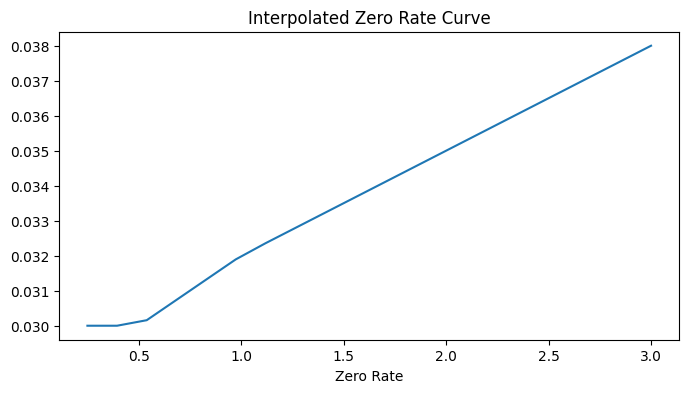

In [11]:
# sanity check on Yield Curve
test_maturities = np.linspace(0.25, 3.0, 20)
rates = [yc.get_zero_rate(T)       for T in test_maturities]
dfs   = [yc.get_discount_factor(T) for T in test_maturities]

plt.figure(figsize=(8,4))
plt.plot(test_maturities, rates)
plt.title("Interpolated Zero Rate Curve")
plt.xlabel("Zero Rate")
plt.show()

In [12]:
S0    = 100
K     = 100
T     = 1.0
sigma = 0.2

call = EuropeanCallOption(
    S=S0,
    K=K,
    T=T,
    sigma=sigma,
    yield_curve=yc
)

put = EuropeanPutOption(
    S=S0,
    K=K,
    T=T,
    sigma=sigma,
    yield_curve=yc
)

In [13]:
# pricing
call_price = float(round(call.price(), 4))
put_price  = float(round(put.price(),  4))

print(f"the call price is ${call_price}")
print(f"the put price  is ${put_price}")

the call price is $9.5146
the put price  is $6.3653


# Sense checks
- volatility should increase both prices
- time to maturity should increase both price as well (calls more than puts)
- S0 should increase call price decrease put price
- K should increase put price, decrease call price

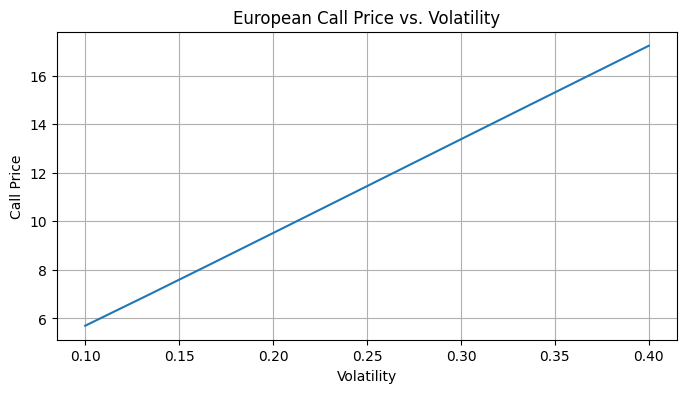

In [14]:
# volatility sanity check
vols       = np.linspace(0.1, 0.4, 10)
call_price = []

for v in vols:
    tmp_call = EuropeanCallOption(S0, K, T, v, yc)
    call_price.append(tmp_call.price())

plt.figure(figsize=(8,4))
plt.plot(vols, call_price)
plt.title("European Call Price vs. Volatility")
plt.xlabel("Volatility")
plt.ylabel("Call Price")
plt.grid(True)
plt.show()